<a href="https://colab.research.google.com/github/hiteshbaghele000-arch/ML-MDM-LAB/blob/main/practical_4_EE539.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries

import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

In [ ]:
# Import Libraries

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix


In [ ]:
#Step 1: Loau Dataset

#

data = pd.read_csv("/wireless_signal_quality_dataset.xlsx - Sheet1 (1).csv")

print("First Five Records")

print(data.head())

print("\nDataset Shape:", data.shape)

First Five Records
   Signal_Strength_dBm  SNR_dB  ...  Estimated_Throughput_Mbps  Quality
0                  -41       6  ...                         18     Poor
1                  -86      25  ...                         55     Poor
2                  -73      27  ...                         81     Fair
3                  -57       5  ...                         15     Poor
4                  -87      15  ...                         21     Poor

[5 rows x 10 columns]

Dataset Shape: (100, 10)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Step 2: Define Features and Target

#

X = data.drop("Quality", axis=1)

y = data["Quality"]


In [ ]:
# Step 3: Encode Target Labels

#

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("\nClass Labels:")

print(encoder.classes_)


Class Labels:
['Excellent' 'Fair' 'Good' 'Poor']


In [ ]:
#Step 4: Split Dataset

#

X_train, X_test, y_train, y_test = train_test_split(

X,
y,

test_size=0.25,

random_state=42,

stratify=y

)

In [ ]:
# Step 5: Train Decision Tree

#

dt = DecisionTreeClassifier(

criterion='gini',

max_depth=5,

)

random_state=42

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
# Step 6: Prediction

#

y_pred = dt.predict(X_test)



In [ ]:
# Step 7: Accuracy

#

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy: {:.2f}%".format(accuracy *1080))


Accuracy: 993.60%


In [ ]:
#Step 8: Confusion Matrix

#

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")

print(cm)



Confusion Matrix
[[ 0  0  1  0]
 [ 0  8  1  0]
 [ 0  0  2  0]
 [ 0  0  0 13]]


In [ ]:
# Step 9: Classification Report

#

print("\nClassification Report")

print(classification_report)

y_test,
y_pred,
target_names=encoder.classes_,



Classification Report
<function classification_report at 0x7f8c30309f80>


In [ ]:
# Step 10: Feature Importance

#



importance = pd.Series(

dt.feature_importances_,

index=X.columns

)

importance = importance.sort_values(ascending=False)

print("\nFeature Importance")

print(importance)


Feature Importance
Signal_Strength_dBm          0.438873
SNR_dB                       0.365448
Estimated_Throughput_Mbps    0.117036
Interference_dB              0.078643
Distance_m                   0.000000
Frequency_GHz                0.000000
Channel_Bandwidth_MHz        0.000000
Noise_Floor_dBm              0.000000
Connected_Devices            0.000000
dtype: float64


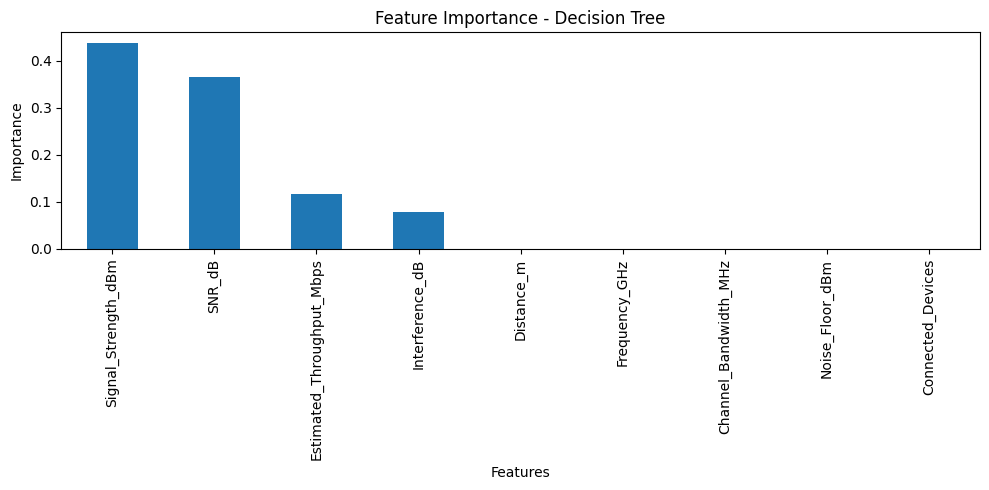

In [ ]:
#Step 11: Plot Feature Importance

#

plt.figure(figsize=(10,5))

importance.plot(kind='bar')

plt.title("Feature Importance - Decision Tree")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.tight_layout()

Text(0.5, 1.0, 'Decision Tree for Fault Detection')

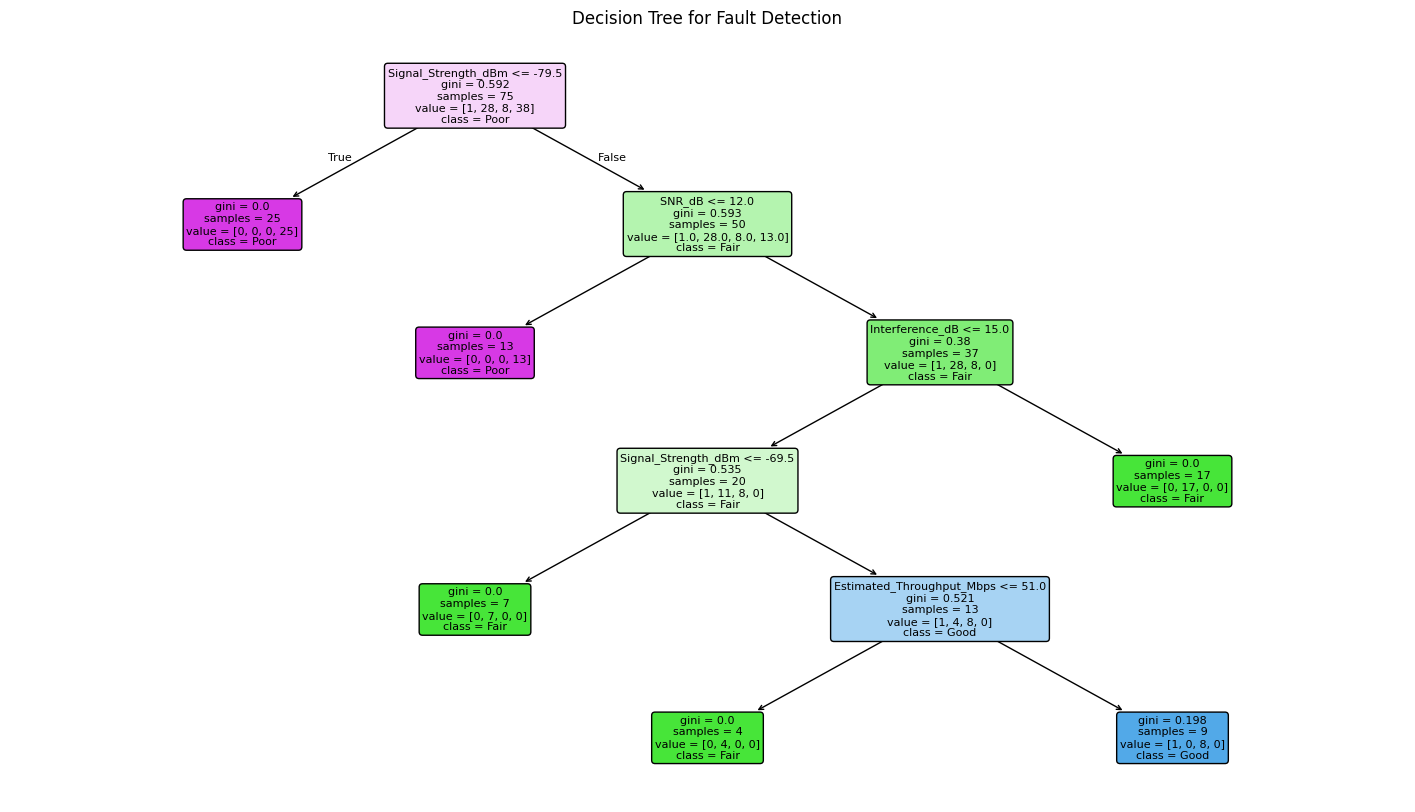

In [ ]:
# Step 12: Visualize Decision Tree

#

plt.figure(figsize=(18,10))

plot_tree(

dt,

feature_names=X.columns,

class_names=encoder.classes_,

filled=True,

rounded=True,

fontsize=8

)

plt.title("Decision Tree for Fault Detection")